# Notebook 05: Model Development

## Purpose

The objective is to develop and evaluate machine learning models that predict a wide receiver's receiving yards for the following NFL season.

Using the engineered dataset we're looking for the best performing model and identifying the variables that contribute most to predicting future receiving production.

In [1]:
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [2]:
data_path = Path("../data/processed/wr_model.csv")

wr_model = pl.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width:,}")

Dataset loaded successfully.
Rows: 2,129
Columns: 139


In [3]:
from pathlib import Path

data_path = Path("../data/processed/wr_model.csv")

print("Path:", data_path.resolve())

wr_model = pl.read_csv(data_path)

print("Rows:", wr_model.height)
print("Columns:", wr_model.width)

Path: C:\Users\billf\Capstone-Project\data\processed\wr_model.csv
Rows: 2129
Columns: 139


In [4]:
# first five observations

wr_model.head()

player_id,season,games,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_cpoe,passing_2pt_conversions,pacr,passing_10,passing_16,passing_20,passing_40,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,rushing_10,rushing_12,rushing_20,rushing_40,receptions,targets,…,fg_missed_60_,fg_made_distance,fg_missed_distance,fg_blocked_distance,pat_made,pat_att,pat_missed,pat_blocked,gwfg_made,gwfg_att,gwfg_missed,gwfg_blocked,pt_att,pt_blocked,pt_yards,pt_inside_20,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards,height,weight,jersey_number,rookie_season,draft_year,draft_round,draft_pick,next_season_receiving_yards,catch_rate,yards_per_reception,yards_per_target,tds_per_reception,first_downs_per_reception
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""00-0015754""",2012,14,0,0,0,0,0,0,0,0,0,0,0,0,null,null,0,null,0,0,0,0,0,0,0,0,0,0,null,0,0,0,0,0,45,59,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,72,194,80,1999,1999,4,105,115,0.762712,12.088889,9.220339,0.111111,0.666667
"""00-0020337""",2012,16,0,0,0,0,0,0,0,0,0,0,0,0,null,null,0,null,0,0,0,0,3,27,0,1,1,1,-3.859167,0,2,1,0,0,73,138,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,69,195,89,2001,2001,3,74,745,0.528986,16.082192,8.507246,0.054795,0.69863
"""00-0020337""",2013,15,0,0,0,0,0,0,0,0,0,0,0,0,null,null,0,null,0,0,0,0,0,0,0,0,0,0,null,0,0,0,0,0,64,110,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,69,195,89,2001,2001,3,74,1065,0.581818,11.640625,6.772727,0.0625,0.6875
"""00-0020337""",2014,16,0,0,0,0,0,0,0,0,0,0,0,0,null,null,0,null,0,0,0,0,0,0,0,0,0,0,null,0,0,0,0,0,79,134,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,69,195,89,2001,2001,3,74,670,0.589552,13.481013,7.947761,0.075949,0.56962
"""00-0020337""",2015,7,0,0,0,0,0,0,0,0,0,0,0,0,null,null,0,null,0,0,0,0,0,0,0,0,0,0,null,0,0,0,0,0,46,73,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,69,195,89,2001,2001,3,74,799,0.630137,14.565217,9.178082,0.065217,0.608696


In [5]:
# dataset information

print("=" * 50)
print("Modeling Dataset Summary")
print("=" * 50)

print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width:,}")

print("\nTarget Variable:")
print("next_season_receiving_yards")

Modeling Dataset Summary
Rows: 2,129
Columns: 139

Target Variable:
next_season_receiving_yards


In [7]:
data_path = Path("../data/processed/wr_model.csv")

wr_model = pl.read_csv(data_path)

expected_rows = 2_129
expected_columns = 139
target = "next_season_receiving_yards"

print("=" * 50)
print("Final Modeling Dataset Validation")
print("=" * 50)

print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width}")
print(f"Target present: {target in wr_model.columns}")

assert wr_model.height == expected_rows, (
    f"Expected {expected_rows:,} rows, but found {wr_model.height:,}."
)

assert wr_model.width == expected_columns, (
    f"Expected {expected_columns} columns, but found {wr_model.width}."
)

assert target in wr_model.columns, (
    f"Target column '{target}' was not found."
)

print("\nDataset validation passed.")

Final Modeling Dataset Validation
Rows: 2,129
Columns: 139
Target present: True

Dataset validation passed.


## Predictors, Target, and Group Variable

The modeling dataset contains one observation for each player and season. The target is next_season_receiving_yards.

player_id is kept for grouping players during validation but is not used as a predictor.

In [8]:
target = "next_season_receiving_yards"
group_column = "player_id"

groups = wr_model[group_column].to_numpy()

X = wr_model.drop([target, group_column])

y = wr_model[target]

feature_names = X.columns

X_array = X.to_numpy()
y_array = y.to_numpy()

print("=" * 50)
print("Predictor Matrix Summary")
print("=" * 50)
print(f"Predictors: {X.width}")
print(f"Observations: {X.height}")
print(f"Unique players: {len(set(groups))}")
print(f"Target: {target}")

Predictor Matrix Summary
Predictors: 137
Observations: 2129
Unique players: 620
Target: next_season_receiving_yards


In [9]:
# Summarize missing values in the final predictor matrix

missing_summary = (
    pl.DataFrame(
        {
            "feature": X.columns,
            "missing_values": [
                X[column].null_count()
                for column in X.columns
            ],
        }
    )
    .with_columns(
        (
            pl.col("missing_values")
            / X.height
            * 100
        )
        .round(2)
        .alias("missing_percent")
    )
    .filter(pl.col("missing_values") > 0)
    .sort("missing_values", descending=True)
)

missing_summary.head(20)

feature,missing_values,missing_percent
str,i64,f64
"""passing_cpoe""",1974,92.72
"""pacr""",1967,92.39
"""passing_epa""",1938,91.03
"""rushing_epa""",1139,53.5
"""draft_year""",585,27.48
…,…,…
"""first_downs_per_reception""",119,5.59
"""racr""",80,3.76
"""receiving_epa""",76,3.57


## Missing Data Strategy

The predictor audit identified 15 variables with missing values. Before modeling, the amount of missing data was reviewed to determine which variables should be removed and which could be imputed.

In [10]:
# Features to remove before modeling

features_to_drop = [
    "passing_cpoe",
    "passing_epa",
    "pacr"
]

print("Features selected for removal:\n")

for feature in features_to_drop:
    percent_missing = (
        missing_summary
        .filter(pl.col("feature") == feature)
        ["missing_percent"]
        .item()
    )

    print(f"{feature:<20} {percent_missing:.2f}% missing")

Features selected for removal:

passing_cpoe         92.72% missing
passing_epa          91.03% missing
pacr                 92.39% missing


In [11]:
# Remove predictors with excessive missingness

features_to_drop = [
    "passing_cpoe",
    "passing_epa",
    "pacr"
]

features_to_drop = [
    feature
    for feature in features_to_drop
    if feature in X.columns
]

X = X.drop(features_to_drop)

# Refresh modeling objects after feature removal
feature_names = X.columns
X_array = X.to_numpy()
y_array = y.to_numpy()

print("=" * 50)
print("Predictor Matrix Updated")
print("=" * 50)

print(f"Predictors remaining: {X.width}")

print("\nRemoved features:")
for feature in features_to_drop:
    print(f"• {feature}")

Predictor Matrix Updated
Predictors remaining: 134

Removed features:
• passing_cpoe
• passing_epa
• pacr


In [12]:
# Review the seasons available in the modeling dataset

(
    wr_model
    .select("season")
    .unique()
    .sort("season")
)

season
i64
2012
2013
2014
2015
2016
…
2020
2021
2022


In [13]:
(
    wr_model
    .group_by("season")
    .len()
    .sort("season")
)

season,len
i64,u32
2012,153
2013,148
2014,150
2015,148
2016,152
…,…
2020,187
2021,186
2022,167


In [14]:
wr_model.columns

['player_id',
 'season',
 'games',
 'completions',
 'attempts',
 'passing_yards',
 'passing_tds',
 'passing_interceptions',
 'sacks_suffered',
 'sack_yards_lost',
 'sack_fumbles',
 'sack_fumbles_lost',
 'passing_air_yards',
 'passing_yards_after_catch',
 'passing_first_downs',
 'passing_epa',
 'passing_cpoe',
 'passing_2pt_conversions',
 'pacr',
 'passing_10',
 'passing_16',
 'passing_20',
 'passing_40',
 'carries',
 'rushing_yards',
 'rushing_tds',
 'rushing_fumbles',
 'rushing_fumbles_lost',
 'rushing_first_downs',
 'rushing_epa',
 'rushing_2pt_conversions',
 'rushing_10',
 'rushing_12',
 'rushing_20',
 'rushing_40',
 'receptions',
 'targets',
 'receiving_yards',
 'receiving_tds',
 'receiving_fumbles',
 'receiving_fumbles_lost',
 'receiving_air_yards',
 'receiving_yards_after_catch',
 'receiving_first_downs',
 'receiving_epa',
 'receiving_2pt_conversions',
 'receiving_10',
 'receiving_16',
 'receiving_20',
 'receiving_40',
 'racr',
 'target_share',
 'air_yards_share',
 'wopr',
 'spec

## Grouped Train-Test Split

The predictor and target data are divided into training and testing datasets using a grouped split based on "player_id". Approximately 80% of the unique players are assigned to the training set and 20% are assigned to the testing set.

All seasons belonging to the same player remain entirely within one dataset. This prevents the model from any data leakage

This accounts for the longitudinal structure of the data, where players contribute repeated observations across multiple seasons. Keeping player records together reduces the risk of overly optimistic model performance caused by player level information leakage.

In [15]:
# Grouped Train/Test Split

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(
        X_array,
        y_array,
        groups=groups
    )
)

X_train = X_array[train_idx]
X_test = X_array[test_idx]

y_train = y_array[train_idx]
y_test = y_array[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("=" * 50)
print("Grouped Train/Test Split Summary")
print("=" * 50)

print(f"Training observations: {len(X_train)}")
print(f"Testing observations : {len(X_test)}")
print(f"Predictors           : {X_train.shape[1]}")

print()
print(f"Training players     : {len(set(groups_train))}")
print(f"Testing players      : {len(set(groups_test))}")

assert len(X_train) == len(y_train), (
    "Training predictors and target are not aligned."
)

assert len(X_test) == len(y_test), (
    "Testing predictors and target are not aligned."
)

assert X_train.shape[1] == X_test.shape[1], (
    "Training and testing datasets have different predictor counts."
)

assert len(X_train) + len(X_test) == len(X_array), (
    "The split does not contain every original observation."
)

print("\nGrouped train/test split validation passed.")

Grouped Train/Test Split Summary
Training observations: 1686
Testing observations : 443
Predictors           : 134

Training players     : 496
Testing players      : 124

Grouped train/test split validation passed.


In [16]:
# Player Leakage Validation

training_players = set(groups_train)
testing_players = set(groups_test)

overlapping_players = training_players.intersection(testing_players)

print("=" * 50)
print("Player Leakage Validation")
print("=" * 50)

print(f"Unique training players : {len(training_players)}")
print(f"Unique testing players  : {len(testing_players)}")
print(f"Players in both datasets: {len(overlapping_players)}")

assert len(overlapping_players) == 0, (
    "Player leakage detected: one or more players appear "
    "in both the training and testing datasets."
)

print("\nValidation passed: no player overlap detected.")

Player Leakage Validation
Unique training players : 496
Unique testing players  : 124
Players in both datasets: 0

Validation passed: no player overlap detected.


## Missing Value Imputation

To prevent data leakage, missing values are replaced using the median calculated from the training dataset only. The fitted imputer is applied to both the training and testing datasets.

Using the training data to estimate replacement values preserves the independence of the testing dataset and produces a more realistic evaluation of model performance.

In [17]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")

X_train = median_imputer.fit_transform(X_train)

X_test = median_imputer.transform(X_test)

print("=" * 50)
print("Missing Value Imputation")
print("=" * 50)

print("Strategy: Median")

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

print("\nImputation completed successfully.")

Missing Value Imputation
Strategy: Median
Training shape: (1686, 134)
Testing shape: (443, 134)

Imputation completed successfully.


## Feature Scaling

Principal Component Analysis and regularized regression are sensitive to differences in predictor scale. The imputed training predictors are therefore standardized using means and standard deviations learned from the training data only. The fitted scaler is then applied to the testing data.

Fitting the scaler only on the training data prevents information from the testing set from influencing preprocessing decisions.

In [18]:
# Standardize predictors using training data only

from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

print("=" * 50)
print("Feature Scaling")
print("=" * 50)
print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")
print("\nFeature scaling completed successfully.")

Feature Scaling
Training shape: (1686, 134)
Testing shape: (443, 134)

Feature scaling completed successfully.


## Principal Component Analysis (PCA)

Principal Component Analysis was evaluated as the unsupervised feature engineering method for this project. The EDA identified substantial correlation among opportunity and production variables, including targets, receptions, receiving first downs, receiving air yards, target share, and related performance measures. Because several predictors describe overlapping aspects of wide receiver production, retaining all 134 predictors may add redundancy without adding equivalent predictive information.

PCA transforms correlated predictors into independent principal components without using the target variable, next_season_receiving_yards. This allows the analysis to test whether the original predictor set can be represented by fewer dimensions while retaining most of its information.

Median imputation and feature scaling were completed before PCA because PCA requires complete numeric data and is sensitive to differences in scale. The PCA model was fitted only on the standardized training data and then applied to the testing data to prevent information leakage.

Principal Component Analysis
Original predictors: 134
Components required for 90% explained variance: 38
Components required for 95% explained variance: 46

Dimensionality reduction at 95% variance:
Reduced from 134 to 46 predictors
Reduction: 88 predictors (65.7%)


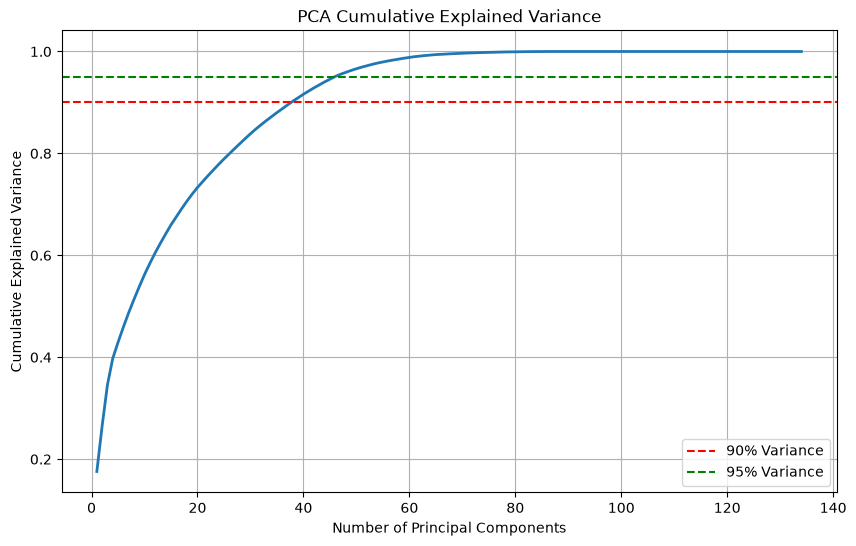

In [19]:
# Fit PCA on the standardized training data

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("=" * 50)
print("Principal Component Analysis")
print("=" * 50)
print(f"Original predictors: {X_train_scaled.shape[1]}")
print(f"Components required for 90% explained variance: {components_90}")
print(f"Components required for 95% explained variance: {components_95}")

reduction = X_train_scaled.shape[1] - components_95
reduction_pct = reduction / X_train_scaled.shape[1] * 100

print(f"\nDimensionality reduction at 95% variance:")
print(f"Reduced from {X_train_scaled.shape[1]} to {components_95} predictors")
print(f"Reduction: {reduction} predictors ({reduction_pct:.1f}%)")

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         linewidth=2)

plt.axhline(0.90, color='red', linestyle='--', label='90% Variance')
plt.axhline(0.95, color='green', linestyle='--', label='95% Variance')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.legend()

plt.show()

## PCA Dataset Creation

The PCA results showed that 46 principal components retained 95 percent of the variance contained in the 134 predictors used for modeling. This reduced the predictor space by 88 dimensions, or 65.7 percent, while preserving most of the information contained in the standardized training data.

The 95 percent PCA representation was selected for model comparison because it provides a conservative balance between reducing redundancy and retaining predictive information. A lower threshold would produce fewer components, but it could also remove variation that contributes to future receiving production.

The transformed training and testing datasets were created using the PCA model fitted only on the standardized training data. 

In [20]:
# Create the PCA datasets using the 95% explained variance threshold

pca_95 = PCA(n_components=0.95)

X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print("=" * 50)
print("PCA Transformed Dataset")
print("=" * 50)
print(f"Training shape: {X_train_pca.shape}")
print(f"Testing shape: {X_test_pca.shape}")
print(f"Number of PCA components: {X_train_pca.shape[1]}")

PCA Transformed Dataset
Training shape: (1686, 46)
Testing shape: (443, 46)
Number of PCA components: 46


## Limitations and Future Improvements

Median imputation was selected because it provides a simple, reproducible, and robust approach for handling missing numeric values while minimizing the influence of extreme observations.

In [21]:
def evaluate_model(model_name, y_true, y_pred):
    """Calculate regression metrics and store model results."""

    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print("=" * 50)
    print(f"{model_name} Performance")
    print("=" * 50)
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.3f}")

    return mae, rmse, r2

## Model Evaluation Setup

All regression models were evaluated using the same testing data and the same three metrics: mean absolute error, root mean squared error, and R squared. 

In [22]:
model_results = []

## PCA Linear Regression

A Linear Regression model was trained using the 46 principal components that retained 95 percent of the training data variance. The purpose of this model was not to assume that PCA would improve performance. Instead, it was used to test whether a smaller, nonredundant representation of the data could achieve performance comparable to the model trained with the original predictors.

This comparison is important for the NFL General Manager because a reduced model may be easier to maintain and less vulnerable to instability caused by highly correlated statistics. However, principal components are combinations of many variables and are less directly interpretable than original football metrics. The PCA model must therefore be evaluated on both predictive performance and practical usefulness.

In [23]:
# Train Linear Regression using PCA components

pca_linear_model = LinearRegression()

pca_linear_model.fit(X_train_pca, y_train)

pca_linear_predictions = pca_linear_model.predict(X_test_pca)

_ = evaluate_model(
    "PCA Linear Regression",
    y_test,
    pca_linear_predictions
)

PCA Linear Regression Performance
MAE : 221.97
RMSE: 296.64
R²  : 0.514


In [24]:
# Create the baseline model

baseline_model = DummyRegressor(strategy="median")


baseline_model.fit(X_train, y_train)


baseline_predictions = baseline_model.predict(X_test)


baseline_mae, baseline_rmse, baseline_r2 = evaluate_model(
    "Dummy Regressor",
    y_test,
    baseline_predictions
)

Dummy Regressor Performance
MAE : 338.91
RMSE: 446.70
R²  : -0.103


## Linear Regression

The model estimates a linear relationship between the predictor variables and next-season receiving yards by fitting coefficients that minimize prediction error on the training data.

In [25]:
# Create the model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae, linear_rmse, linear_r2 = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

Linear Regression Performance
MAE : 224.57
RMSE: 304.43
R²  : 0.488


## Ridge Regression

Ridge Regression was included because the EDA identified substantial correlation among player opportunity and production measures. The standardized training and testing datasets created during preprocessing were reused so that coefficient penalties were applied consistently across predictors.

In [26]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_predictions = ridge_model.predict(X_test_scaled)

ridge_mae, ridge_rmse, ridge_r2 = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_predictions
)

Ridge Regression Performance
MAE : 223.96
RMSE: 303.60
R²  : 0.491


## Lasso Regression

Lasso Regression can reduce some coefficients to exactly zero. This effectively removes less important predictors from the model, resulting in automatic feature selection.

Because Lasso Regression is sensitive to predictor scale, the standardized training and testing datasets created for Ridge Regression are reused.

In [27]:
lasso_model = Lasso(alpha=1.0, random_state=42)

lasso_model.fit(X_train_scaled, y_train)

lasso_predictions = lasso_model.predict(X_test_scaled)

lasso_mae, lasso_rmse, lasso_r2 = evaluate_model(
    "Lasso Regression",
    y_test,
    lasso_predictions
)

Lasso Regression Performance
MAE : 221.00
RMSE: 297.40
R²  : 0.511


## Lasso Feature Selection Results

Lasso retained 64 predictors and removed 70 by reducing their coefficients to zero. This provides a supervised feature-selection approach because predictor retention was determined using the relationship between the features and next-season receiving yards.

For the NFL General Manager, this approach preserves the original football metrics and therefore offers greater interpretability than PCA, whose components combine information from many variables.

In [28]:
lasso_features = (
    pl.DataFrame({
        "Feature": feature_names,
        "Coefficient": lasso_model.coef_
    })
)

selected_features_df = (
    lasso_features
    .filter(pl.col("Coefficient") != 0)
    .sort("Coefficient", descending=True)
)

selected_features_df

Feature,Coefficient
str,f64
"""receptions""",65.819777
"""air_yards_share""",64.22529
"""rookie_season""",45.754895
"""receiving_yards_after_catch""",40.648589
"""receiving_10""",39.011755
…,…
"""rushing_12""",-16.157789
"""fumbles_out_of_bounds""",-17.223955
"""draft_round""",-24.52227


In [29]:
# Features removed by Lasso

removed_features_df = (
    lasso_features
    .filter(pl.col("Coefficient") == 0)
    .sort("Feature")
)

removed_features_df

Feature,Coefficient
str,f64
"""carries""",0.0
"""def_fumbles""",-0.0
"""def_qb_hits""",0.0
"""def_sack_yards""",0.0
"""def_sacks""",0.0
…,…
"""rushing_yards""",0.0
"""special_teams_tds""",-0.0
"""targets""",0.0


In [30]:
# Count selected features

selected_features = (lasso_model.coef_ != 0).sum()
removed_features = (lasso_model.coef_ == 0).sum()

print("=" * 50)
print("Feature Selection Summary")
print("=" * 50)

print(f"Selected features : {selected_features}")
print(f"Removed features  : {removed_features}")

Feature Selection Summary
Selected features : 64
Removed features  : 70


## Final Model Comparison

The table below summarizes the predictive performance of all regression models evaluated during this analysis. Comparing the models using the same evaluation metrics provides a consistent basis for selecting the approach that offers the best balance of predictive accuracy, model complexity, and interpretability.

For the NFL General Manager, the preferred model is not necessarily the most complex model, but the one that provides accurate and actionable forecasts of future receiving production.

In [31]:
results_df = (
    pl.DataFrame(model_results)
    .sort("RMSE")
)

results_df

Model,MAE,RMSE,R2
str,f64,f64,f64
"""PCA Linear Regression""",221.969572,296.643423,0.513735
"""Lasso Regression""",220.999716,297.400525,0.51125
"""Ridge Regression""",223.962596,303.600169,0.490661
"""Linear Regression""",224.5719,304.426286,0.487885
"""Dummy Regressor""",338.909707,446.700376,-0.102645
